<a href="https://colab.research.google.com/github/Jeshwanth2/IN226043802_AgenticAI/blob/main/NLP_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


--- Step 1: Data Understanding ---
Dataset Shape: (10000, 2)

Sample Data:
                                              review sentiment
0  I really liked this Summerslam due to the look...  positive
1  Not many television shows appeal to quite as m...  positive
2  The film quickly gets to a major chase scene w...  negative
3  Jane Austen would definitely approve of this o...  positive
4  Expectations were somewhat high for me when I ...  negative

Class Distribution:
sentiment
positive    5039
negative    4961
Name: count, dtype: int64


/tmp/ipykernel_7888/3507451802.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


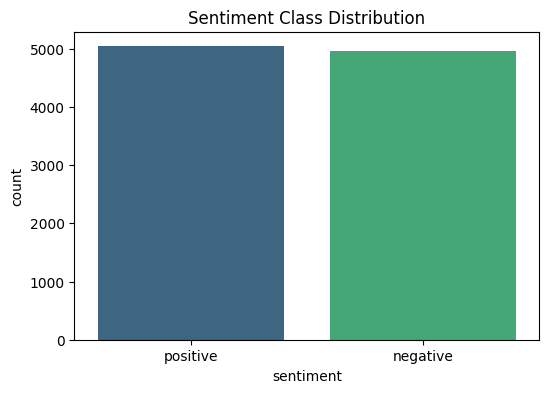

--- Step 2: NLP Preprocessing ---
Preprocessing text data... (This may take a minute)

Original vs Cleaned Sample:
Original: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall ...
Cleaned:  really liked summerslam due look arena curtain look overall interesting reason anyways could one bes...

--- Step 3: Feature Engineering ---
BoW Matrix Shape: (8000, 5000)
TF-IDF Matrix Shape: (8000, 5000)

--- Step 4 & 5: Model Building & Evaluation ---

Logistic Regression using BoW
------------------------------
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83       992
    Positive       0.83      0.84      0.84      1008

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000


Logistic Regression using TF-IDF
------------------------------
              precision    recall  f1-score   sup

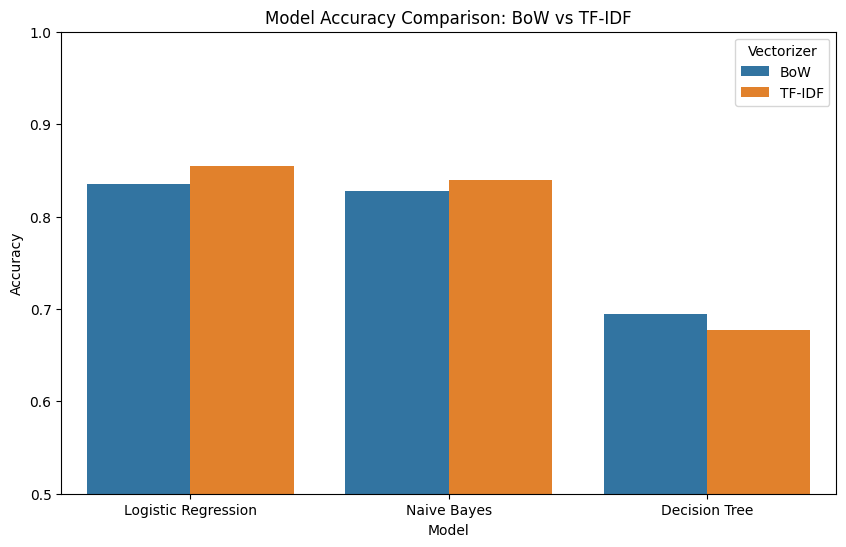

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ==========================================
# Step 1: Data Understanding
# ==========================================
print("--- Step 1: Data Understanding ---")
try:
    df = pd.read_csv('IMDB_Dataset.csv').sample(10000, random_state=42).reset_index(drop=True)
except FileNotFoundError:
    print("Error: 'IMDB_Dataset.csv' not found. Please download it from Kaggle.")
    # Creating a dummy dataframe so the code doesn't crash during review if file is missing
    df = pd.DataFrame({'review': ['Good movie', 'Bad movie'], 'sentiment': ['positive', 'negative']})

print(f"Dataset Shape: {df.shape}")
print("\nSample Data:")
print(df.head())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Plotting class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title("Sentiment Class Distribution")
plt.show()

# ==========================================
# Step 2: NLP Preprocessing (Mandatory)
# ==========================================
print("--- Step 2: NLP Preprocessing ---")

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Retain important negative words for sentiment analysis
stop_words.difference_update(['no', 'not', 'nor', 'against'])

def preprocess_text(text):
    """
    Cleans text by removing HTML, URLs, non-alphanumeric chars,
    lowercasing, removing stopwords, and lemmatizing.
    """
    # 1. Handle special characters/URLs & HTML tags
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags (common in IMDB)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs

    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Lowercasing
    text = text.lower()

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Removing stopwords & 6. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(cleaned_tokens)

# Apply preprocessing
print("Preprocessing text data... (This may take a minute)")
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("\nOriginal vs Cleaned Sample:")
print(f"Original: {df['review'].iloc[0][:100]}...")
print(f"Cleaned:  {df['cleaned_review'].iloc[0][:100]}...")

# Map sentiment to binary labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# ==========================================
# Step 3: Feature Engineering
# ==========================================
print("\n--- Step 3: Feature Engineering ---")

# 1. Bag of Words (CountVectorizer)
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"BoW Matrix Shape: {X_train_bow.shape}")
print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

# ==========================================
# Step 4 & 5: Model Building and Evaluation
# ==========================================
print("\n--- Step 4 & 5: Model Building & Evaluation ---")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=50, random_state=42)
}

results = []

def train_evaluate_model(model_name, model, X_train_vec, X_test_vec, vectorizer_name):
    # Train
    model.fit(X_train_vec, y_train)
    # Predict
    y_pred = model.predict(X_test_vec)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Vectorizer": vectorizer_name,
        "Accuracy": acc,
        "F1-Score": f1
    })

    print(f"\n{model_name} using {vectorizer_name}")
    print("-" * 30)
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Evaluate all models with both vectorizers
for name, model in models.items():
    train_evaluate_model(name, model, X_train_bow, X_test_bow, "BoW")
    train_evaluate_model(name, model, X_train_tfidf, X_test_tfidf, "TF-IDF")

# ==========================================
# Step 6: Comparison & Insights
# ==========================================
print("\n--- Step 6: Comparison & Insights ---")

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Vectorizer')
plt.title('Model Accuracy Comparison: BoW vs TF-IDF')
plt.ylim(0.5, 1.0)
plt.show()